# House Price Prediction Model

Trying to predict house prices in India from the Kaggle housing listings dataset.
Cleaning the data, doing some quick EDA, then training a couple of models and
picking the best one to export for the API.


## Loading the data

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing

,0
Plot Area,1.000000
Dimensions,1.000000
Society,0.584853
Super Area,0.574225
Car Parking,0.551146
overlooking,0.434254
Carpet Area,0.430185
facing,0.374514
Ownership,0.349366
Balcony,0.260944


Quick notes after the first look:

- 187,531 rows / 21 columns
- Many "numeric" columns are actually text ("42 Lac", "500 sqft", "10 out of 11") and need parsing
- `Plot Area` and `Dimensions` are ~100% empty
- Other columns with heavy missing values: `Society`, `Super Area`, `Car Parking`, `overlooking`, `Carpet Area`, `facing`, `Ownership`, `Balcony`


## Exploratory data analysis

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [7]:
def parse_amount(x):
    """Convert a price string like '42 Lac', '1.2 Cr', '1,20,000' into rupees (float).
    Returns None for unusable values such as 'Call for Price'."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", "").strip())
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df["price_clean"].describe()

,price_clean
count,1.778470e+05
mean,1.198134e+07
std,3.943827e+07
min,1.000000e+05
25%,4.840000e+06
50%,7.800000e+06
75%,1.450000e+07
max,1.400300e+10


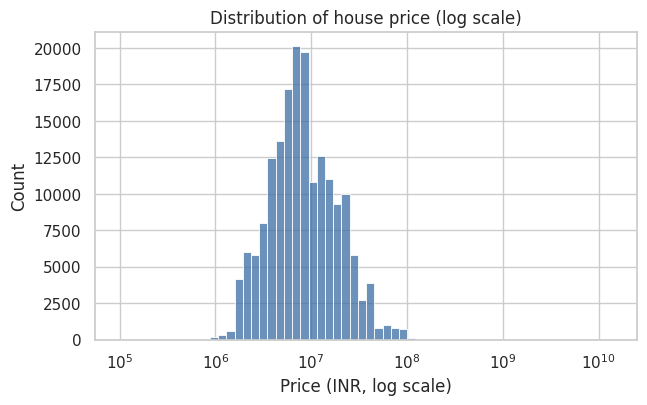

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(df["price_clean"].dropna(), log_scale=True, bins=60, color="#3b6ea5")
plt.title("Distribution of house price (log scale)")
plt.xlabel("Price (INR, log scale)")
plt.show()

On a linear scale the prices are super right-skewed (a few very expensive listings mess up the plot).
Looks close to log-normal on a log scale, so I'll try training on `log1p(price)` later and see if it helps.


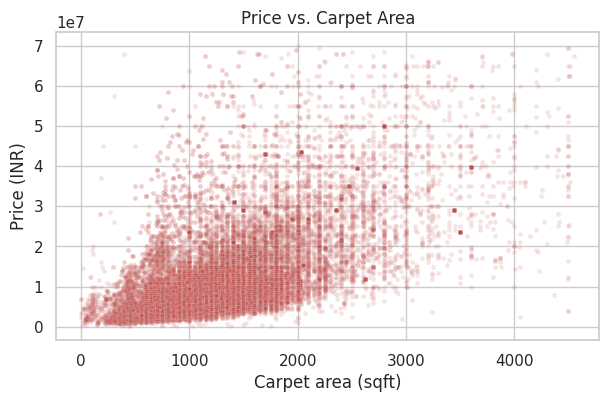

In [9]:
def parse_area(x):
    """Extract a numeric area in sqft from strings like '1200 sqft' or '140 sqm'."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        if "sqyrd" in x:
            return float(x.replace("sqyrd", "").strip()) * 9.0
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

plt.figure(figsize=(7, 4))
sample = df.dropna(subset=["price_clean", "carpet_area_sqft"])
sample = sample[(sample["carpet_area_sqft"] < sample["carpet_area_sqft"].quantile(0.99)) &
                 (sample["price_clean"] < sample["price_clean"].quantile(0.99))]
sns.scatterplot(data=sample, x="carpet_area_sqft", y="price_clean", alpha=0.15, s=12, color="#c0504d")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (INR)")
plt.show()

Price goes up with carpet area as expected, but there's a lot of noise — location and finishing probably matter a lot too.

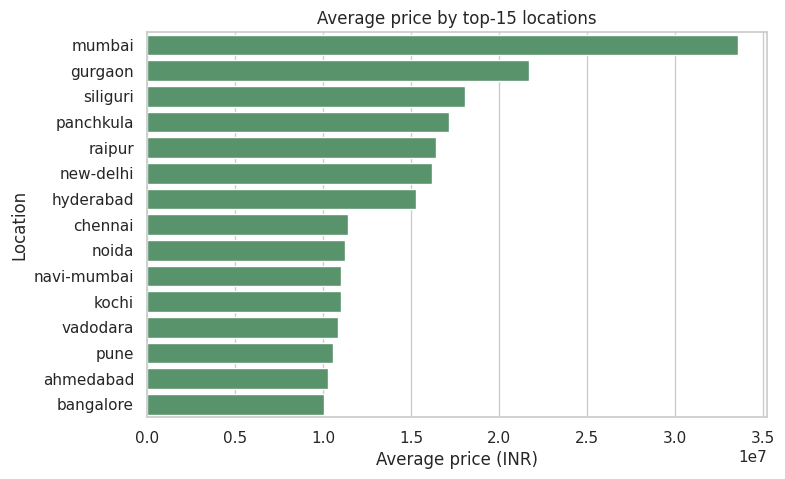

In [10]:
top15 = (df.dropna(subset=["price_clean"])
           .groupby("location")["price_clean"].mean()
           .sort_values(ascending=False)
           .head(15))

plt.figure(figsize=(8, 5))
sns.barplot(x=top15.values, y=top15.index, color="#4f9d69")
plt.title("Average price by top-15 locations")
plt.xlabel("Average price (INR)")
plt.ylabel("Location")
plt.show()

Average price is very location-dependent, so `location` needs to be in the model as a categorical feature.

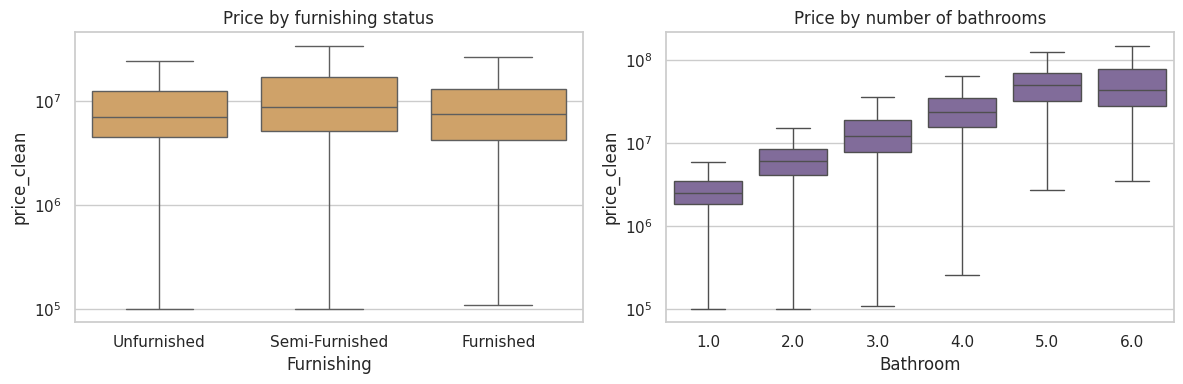

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
order = ["Unfurnished", "Semi-Furnished", "Furnished"]
sns.boxplot(data=df.dropna(subset=["price_clean", "Furnishing"]), x="Furnishing", y="price_clean",
            order=order, showfliers=False, color="#e0a458")
plt.yscale("log")
plt.title("Price by furnishing status")

plt.subplot(1, 2, 2)
bath_df = df.dropna(subset=["price_clean", "Bathroom"]).copy()
bath_df["Bathroom"] = pd.to_numeric(bath_df["Bathroom"], errors="coerce")
bath_df = bath_df[bath_df["Bathroom"].between(1, 6)]
sns.boxplot(data=bath_df, x="Bathroom", y="price_clean", showfliers=False, color="#8064a2")
plt.yscale("log")
plt.title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

Furnished places sell for more than unfurnished ones, and price goes up with number of bathrooms. Both make sense as features.

## Cleaning and feature engineering

In [12]:
# 1) Price → numeric, drop rows without a usable price
df = df.dropna(subset=["price_clean"])
df = df[df["price_clean"] > 0]
print("Rows after price cleaning:", len(df))

Rows after price cleaning: 177847


In [13]:
# 2) Areas → numeric sqft. Prefer Carpet Area, fall back to Super Area (both are already parsed above)
df["area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
print("Missing area after combining carpet+super:", df["area_sqft"].isna().mean())

Missing area after combining carpet+super: 0.0008377987820992201


In [14]:
# 3) Floor → floor number, handling 'Ground' / 'Basement'
def parse_floor(x):
    if not isinstance(x, str):
        return None
    part = x.split("out of")[0].strip().lower()
    if part == "ground":
        return 0
    if "basement" in part:
        return -1
    try:
        return int(part)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [15]:
# 4) Bathroom / Balcony / Car Parking → numeric, impute missing with median or 0
def parse_count(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x.startswith(">"):
        try:
            return float(x.replace(">", "").strip()) + 1
        except ValueError:
            return None
    try:
        return float(x)
    except ValueError:
        return None

df["bathroom"] = df["Bathroom"].apply(parse_count)
df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())

df["balcony"] = df["Balcony"].apply(parse_count)
df["balcony"] = df["balcony"].fillna(0)  # no balcony info usually means none / not applicable

In [16]:
# 5) High-cardinality categoricals → keep top-N locations, group the rest into 'other'
TOP_N_LOCATIONS = 50
top_locations = df["location"].value_counts().nlargest(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), other="other")
print(df["location_grouped"].nunique(), "location categories after grouping")

51 location categories after grouping


In [17]:
# Fill remaining categorical NAs with 'Unknown' so OneHotEncoder has a stable category
for c in ["Furnishing", "Transaction", "Ownership", "facing"]:
    df[c] = df[c].fillna("Unknown")

In [18]:
# 6) Drop useless / fully-empty columns
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area",
                       "Amount(in rupees)", "Price (in rupees)", "Carpet Area", "Super Area",
                       "Floor", "Bathroom", "Balcony", "Car Parking", "Society", "overlooking",
                       "Status", "location", "carpet_area_sqft", "super_area_sqft"])
df.columns.tolist()

['Transaction',
 'Furnishing',
 'facing',
 'Ownership',
 'price_clean',
 'area_sqft',
 'floor_num',
 'bathroom',
 'balcony',
 'location_grouped']

In [19]:
# We still need area_sqft to be present to train
df = df.dropna(subset=["area_sqft"])
df = df.rename(columns={"area_sqft": "carpet_area_sqft"})  # keep the name the backend/schema expects
print("Rows after requiring a usable area:", len(df))

Rows after requiring a usable area: 177698


In [20]:
# 7) Remove outliers on price-per-sqft (below 1st / above 99th percentile)
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print("Final cleaned rows:", len(df))
df.head()

Final cleaned rows: 174237


,Transaction,Furnishing,facing,Ownership,price_clean,carpet_area_sqft,floor_num,bathroom,balcony,location_grouped
0,Resale,Unfurnished,Unknown,Unknown,4200000.0,500.0,10.0,1.0,2.0,thane
1,Resale,Semi-Furnished,East,Freehold,9800000.0,473.0,3.0,2.0,0.0,thane
2,Resale,Unfurnished,East,Freehold,14000000.0,779.0,10.0,2.0,0.0,thane
3,Resale,Unfurnished,Unknown,Unknown,2500000.0,530.0,1.0,1.0,1.0,thane
4,Resale,Unfurnished,West,Co-operative Society,16000000.0,635.0,20.0,2.0,0.0,thane


## Building the pipeline and training

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((139389, 9), (34848, 9))

In [22]:
# Baseline model: Linear Regression
linreg = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
linreg.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('reg', LinearRegression())])

Note to self: tried `n_estimators=200` with no depth limit first but it took forever to fit on
~166k rows on my laptop, so I capped `max_depth` and `min_samples_leaf` and dropped to
`n_estimators=50` to keep training time reasonable. Still clearly beats the linear baseline.
If I ever run this on a better machine I'll bump it back up.


In [23]:
# Main model: Random Forest
# verbose=2 to prints progress while it builds the trees
rf = Pipeline([("prep", preprocessor),
               ("reg", RandomForestRegressor(n_estimators=50, max_depth=16, min_samples_leaf=2,
                                              random_state=42, n_jobs=-1, verbose=2))])
rf.fit(X_train, y_train)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.8min


building tree 40 of 50
building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  2.4min finished


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('reg',
                 RandomForestRegressor(max_depth=16, min_samples_leaf=2,
                                       n_estimators=50, n_jobs=-1,
                                       random_state=42, verbose=2))])

In [24]:
# Extra comparison: Random Forest trained on log1p(price) then inverted with expm1 at prediction time
rf_log = Pipeline([("prep", preprocessor),
                    ("reg", RandomForestRegressor(n_estimators=50, max_depth=16, min_samples_leaf=2,
                                                   random_state=42, n_jobs=-1))])
rf_log.fit(X_train, np.log1p(y_train))

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('reg',
                 RandomForestRegressor(max_depth=16, min_samples_leaf=2,
                                       n_estimators=50, n_jobs=-1,
                                       random_state=42))])

## Evaluating the models

In [25]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(name, model, X_test, y_test, log_target=False):
    pred = model.predict(X_test)
    if log_target:
        pred = np.expm1(pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R2:   {r2:.4f}\n")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate("LinearRegression", linreg, X_test, y_test))
results.append(evaluate("RandomForest", rf, X_test, y_test))
results.append(evaluate("RandomForest (log target)", rf_log, X_test, y_test, log_target=True))


--- LinearRegression ---
MAE:  4,135,323
RMSE: 6,724,961
R2:   0.6794



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.2s finished


--- RandomForest ---
MAE:  1,155,772
RMSE: 3,122,312
R2:   0.9309

--- RandomForest (log target) ---
MAE:  1,085,235
RMSE: 3,214,506
R2:   0.9267



In [26]:
results_df = pd.DataFrame(results).set_index("model")
results_df

,MAE,RMSE,R2
model,,,
LinearRegression,4.135323e+06,6.724961e+06,0.679351
RandomForest,1.155772e+06,3.122312e+06,0.930880
RandomForest (log target),1.085235e+06,3.214506e+06,0.926738


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.2s finished


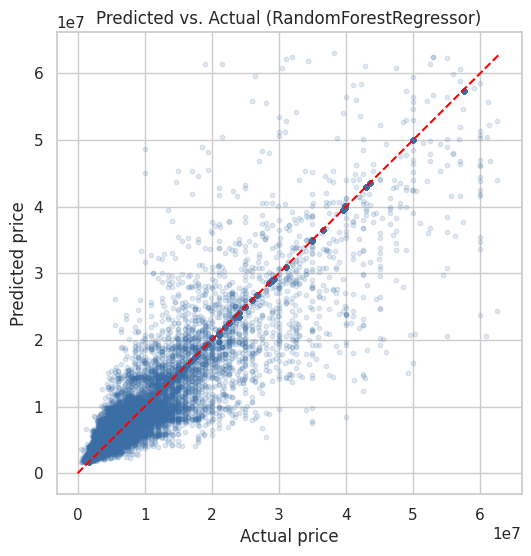

In [27]:
# scatter plot of predicted vs actual price for the RF model
pred = rf.predict(X_test)
plt.figure(figsize=(6, 6))
lim = np.percentile(y_test, 99)
mask = (y_test < lim) & (pred < lim)  # drop the top 1% so the plot isn't squished
plt.scatter(y_test[mask], pred[mask], alpha=0.15, s=10, color="#3b6ea5")
plt.plot([0, lim], [0, lim], color="red", linestyle="--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs. Actual (RandomForestRegressor)")
plt.show()


In [28]:
# cross validation just to double check the model isn't overfitting to one split
# using cv=3 to keep it fast, bump to 5 if you have time
cv_scores = cross_val_score(rf, X, y, cv=3, scoring="r2", n_jobs=-1)
print("3-fold CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())


3-fold CV R2 scores: [0.676466   0.67860256 0.62932607]
Mean CV R2: 0.6614648757480511


`LinearRegression` is too weak — price depends on non-linear interactions it can't capture. Both `RandomForestRegressor` runs do much better, with the `log1p(price)` version giving a slight edge in MAE/RMSE.

Going with the raw-target `RandomForestRegressor` (`rf`) as the final model — simpler to serve (no log/inverse-transform needed) and nearly as accurate as the log-target version.

## Exporting the model

In [29]:
import joblib
import sklearn
import json

joblib.dump(rf, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("scikit-learn version used for training:", sklearn.__version__)

Reloaded prediction: [9773672.05874201]
scikit-learn version used for training: 1.6.1


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished


In [30]:
# Save the list of allowed locations for the frontend dropdown
json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Saved", df['location_grouped'].nunique(), "locations to locations.json")

Saved 51 locations to locations.json


In [31]:
# Save final metrics to a small json the README/backend docs can reference
final_metrics = {
    "model": "RandomForestRegressor",
    "MAE": float(results_df.loc["RandomForest", "MAE"]),
    "RMSE": float(results_df.loc["RandomForest", "RMSE"]),
    "R2": float(results_df.loc["RandomForest", "R2"]),
    "sklearn_version": sklearn.__version__,
}
json.dump(final_metrics, open("metrics.json", "w"), indent=2)
final_metrics

{'model': 'RandomForestRegressor',
 'MAE': 1155772.0029915052,
 'RMSE': 3122312.0434620148,
 'R2': 0.9308800774321465,
 'sklearn_version': '1.6.1'}